In [ ]:
import os
import kagglehub
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("Mengecek dan mengunduh dataset dari Kaggle...")
# Download dataset (otomatis di-cache agar tidak download ulang berkali-kali)
dataset_path = kagglehub.dataset_download("anggadwisunarto/potholes-detection-yolov8")
print(f"Dataset berhasil diakses di lokasi: {dataset_path}")

# Tentukan folder yang akan diuji (kita pakai folder 'valid')
IMAGE_DIR = os.path.join(dataset_path, 'valid', 'images')
LABEL_DIR = os.path.join(dataset_path, 'valid', 'labels')

Mengecek dan mengunduh dataset dari Kaggle...


100%|██████████| 718M/718M [00:08<00:00, 93.8MB/s]

Extracting files...


Dataset berhasil diakses di lokasi: /root/.cache/kagglehub/datasets/anggadwisunarto/potholes-detection-yolov8/versions/3


# **METODE YANG DIPAKAI : YOLO dan CANNY**

In [ ]:
def parse_yolo_label(label_path, img_width, img_height):
    """Membaca koordinat lubang dari file .txt YOLO dan mengubahnya ke pixel."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as file:
        for line in file.readlines():
            data = line.strip().split()
            x_center, y_center, w, h = map(float, data[1:])

            x1 = max(0, int((x_center - w / 2) * img_width))
            y1 = max(0, int((y_center - h / 2) * img_height))
            x2 = min(img_width, int((x_center + w / 2) * img_width))
            y2 = min(img_height, int((y_center + h / 2) * img_height))
            boxes.append([x1, y1, x2, y2])
    return boxes

def process_roi_and_extract_features(image, box):
    """Memotong area lubang (Crop) dan melakukan ekstraksi fitur Canny."""
    x1, y1, x2, y2 = box
    roi = image[y1:y2, x1:x2]
    if roi.size == 0:
        return None, None

    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)
    roi_edges = cv2.Canny(roi_blur, 100, 200)
    return roi, roi_edges

def analyze_severity(box, edges):
    """Menganalisis tingkat keparahan berdasarkan luas dan tekstur."""
    x1, y1, x2, y2 = box
    luas_area = (x2 - x1) * (y2 - y1)
    kepadatan_edge = cv2.countNonZero(edges)
    rasio_kerusakan = kepadatan_edge / luas_area if luas_area > 0 else 0

    if luas_area > 50000 or rasio_kerusakan > 0.15:
        return "PARAH", (255, 0, 0), luas_area, kepadatan_edge
    elif luas_area > 20000 or rasio_kerusakan > 0.08:
        return "SEDANG", (255, 255, 0), luas_area, kepadatan_edge
    else:
        return "RINGAN", (0, 255, 0), luas_area, kepadatan_edge

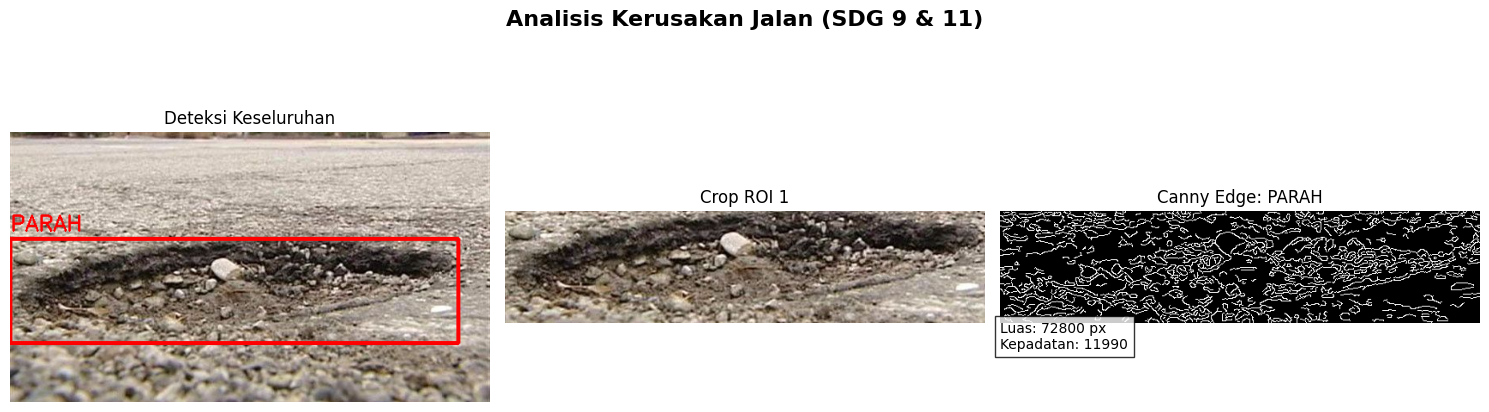

In [ ]:
# 1. Ambil otomatis satu gambar dari folder dataset
daftar_gambar = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]

if not daftar_gambar:
    print("Gambar tidak ditemukan!")
else:
    # Set gambar yang akan dianalisis
    image_name = daftar_gambar[0]
    label_name = image_name.replace('.jpg', '.txt')

    img_path = os.path.join(IMAGE_DIR, image_name)
    txt_path = os.path.join(LABEL_DIR, label_name)

    # 2. Baca Gambar
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape

    # 3. Ambil Lokasi Lubang (Pembacaan Label YOLO)
    boxes = parse_yolo_label(txt_path, w, h)

    if not boxes:
         print("Tidak ada label/kerusakan pada gambar ini.")
    else:
        # 4. Siapkan Canvas Gambar untuk Laporan
        fig = plt.figure(figsize=(15, 5 * len(boxes)))
        fig.suptitle('Analisis Kerusakan Jalan (SDG 9 & 11)', fontsize=16, fontweight='bold')

        # 5. Loop Pemrosesan
        for i, box in enumerate(boxes):
            roi_color, roi_edges = process_roi_and_extract_features(img_bgr, box)
            if roi_color is None: continue

            keparahan, warna, luas, edge_density = analyze_severity(box, roi_edges)

            x1, y1, x2, y2 = box
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), warna, 3)
            cv2.putText(img_rgb, keparahan, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, warna, 2)

            # Tampilkan Hasil Kolom per Kolom
            ax1 = fig.add_subplot(len(boxes), 3, i*3 + 1)
            ax1.imshow(img_rgb)
            ax1.set_title('Deteksi Keseluruhan')
            ax1.axis('off')

            ax2 = fig.add_subplot(len(boxes), 3, i*3 + 2)
            ax2.imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
            ax2.set_title(f'Crop ROI {i+1}')
            ax2.axis('off')

            ax3 = fig.add_subplot(len(boxes), 3, i*3 + 3)
            ax3.imshow(roi_edges, cmap='gray')
            ax3.set_title(f'Canny Edge: {keparahan}')

            # BAGIAN YANG DIPERBAIKI: roi_edges.shape
            ax3.text(0, roi_edges.shape[0] + 30, f"Luas: {luas} px\nKepadatan: {edge_density}", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
            ax3.axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

# **PERBANDINGAN CANNY VS SOBEL**

In [ ]:
def parse_yolo_label(label_path, img_width, img_height):
    """Membaca koordinat dari file YOLO dan mengubahnya ke pixel"""
    boxes = []
    if not os.path.exists(label_path): return boxes
    with open(label_path, 'r') as file:
        for line in file.readlines():
            data = line.strip().split()
            x_center, y_center, w, h = map(float, data[1:])
            x1 = max(0, int((x_center - w / 2) * img_width))
            y1 = max(0, int((y_center - h / 2) * img_height))
            x2 = min(img_width, int((x_center + w / 2) * img_width))
            y2 = min(img_height, int((y_center + h / 2) * img_height))
            boxes.append([x1, y1, x2, y2])
    return boxes

def process_roi_and_extract_features(image, box):
    """Mengekstrak fitur membandingkan Canny dan Sobel"""
    x1, y1, x2, y2 = box
    roi = image[y1:y2, x1:x2]
    if roi.size == 0: return None, None, None

    # Preprocessing
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)

    # Metode 1: CANNY
    roi_canny = cv2.Canny(roi_blur, 100, 200)

    # Metode 2: SOBEL
    sobelx = cv2.Sobel(roi_blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(roi_blur, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobelx, sobely)
    roi_sobel = cv2.convertScaleAbs(sobel_combined)

    return roi, roi_canny, roi_sobel

def analyze_severity(box, edges_canny):
    """Menentukan tingkat keparahan berdasarkan luas dan rasio tekstur Canny"""
    x1, y1, x2, y2 = box
    luas_area = (x2 - x1) * (y2 - y1)
    kepadatan_edge = cv2.countNonZero(edges_canny)
    rasio_kerusakan = kepadatan_edge / luas_area if luas_area > 0 else 0

    if luas_area > 50000 or rasio_kerusakan > 0.15:
        return "PARAH", (255, 0, 0), luas_area, kepadatan_edge
    elif luas_area > 20000 or rasio_kerusakan > 0.08:
        return "SEDANG", (255, 255, 0), luas_area, kepadatan_edge
    else:
        return "RINGAN", (0, 255, 0), luas_area, kepadatan_edge

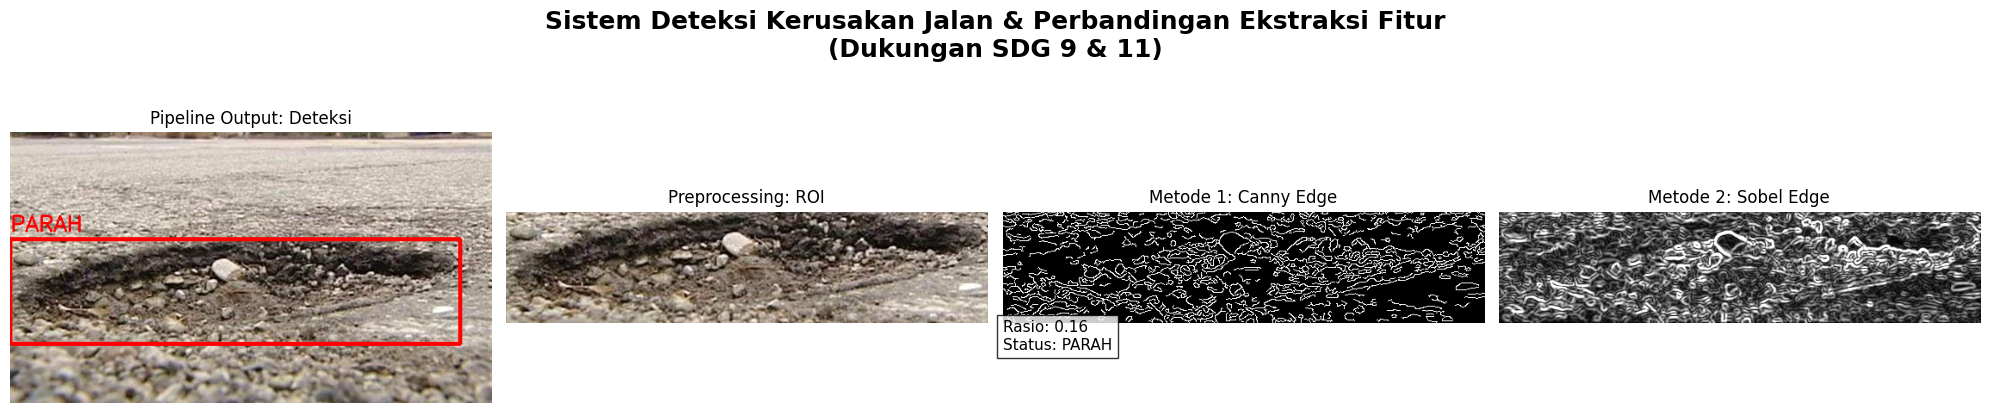

In [ ]:
# 1. Ambil otomatis gambar pertama dari folder
daftar_gambar = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]

if not daftar_gambar:
    print("Gambar tidak ditemukan!")
else:
    # Set gambar yang akan dianalisis (Sudah ditambahkan)
    image_name = daftar_gambar[0]
    label_name = image_name.replace('.jpg', '.txt')

    img_path = os.path.join(IMAGE_DIR, image_name)
    txt_path = os.path.join(LABEL_DIR, label_name)

    # 2. Baca Gambar dan Label
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape
    boxes = parse_yolo_label(txt_path, w, h)

    if not boxes:
         print("Tidak ada label/kerusakan pada gambar ini.")
    else:
        # 3. Siapkan Canvas Gambar (Lebih lebar untuk 4 kolom)
        fig = plt.figure(figsize=(20, 5 * len(boxes)))
        fig.suptitle('Sistem Deteksi Kerusakan Jalan & Perbandingan Ekstraksi Fitur\n(Dukungan SDG 9 & 11)', fontsize=18, fontweight='bold')

        # 4. Loop Pemrosesan
        for i, box in enumerate(boxes):
            roi_color, roi_canny, roi_sobel = process_roi_and_extract_features(img_bgr, box)
            if roi_color is None: continue

            keparahan, warna, luas, edge_density = analyze_severity(box, roi_canny)

            x1, y1, x2, y2 = box
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), warna, 3)
            cv2.putText(img_rgb, keparahan, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, warna, 2)

            # --- Tampilkan Hasil di 4 Kolom ---

            # Kolom 1: Hasil Deteksi Utuh
            ax1 = fig.add_subplot(len(boxes), 4, i*4 + 1)
            ax1.imshow(img_rgb)
            ax1.set_title('Pipeline Output: Deteksi')
            ax1.axis('off')

            # Kolom 2: Potongan ROI
            ax2 = fig.add_subplot(len(boxes), 4, i*4 + 2)
            ax2.imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
            ax2.set_title('Preprocessing: ROI')
            ax2.axis('off')

            # Kolom 3: Canny Edge (Metode 1)
            ax3 = fig.add_subplot(len(boxes), 4, i*4 + 3)
            ax3.imshow(roi_canny, cmap='gray')
            ax3.set_title('Metode 1: Canny Edge')
            # Sudah diperbaiki dengan roi_canny.shape
            ax3.text(0, roi_canny.shape[0] + 30, f"Rasio: {(edge_density/luas):.2f}\nStatus: {keparahan}", fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
            ax3.axis('off')

            # Kolom 4: Sobel Edge (Metode 2)
            ax4 = fig.add_subplot(len(boxes), 4, i*4 + 4)
            ax4.imshow(roi_sobel, cmap='gray')
            ax4.set_title('Metode 2: Sobel Edge')
            ax4.axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

# **TRAINING DATA (COBA DARI AWAL)**

In [ ]:
!pip install ultralytics
import kagglehub

# Download dataset (jika belum)
path = kagglehub.dataset_download("anggadwisunarto/potholes-detection-yolov8")
print("Path ke dataset:", path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.4 MB/s eta 0:00:00
Using Colab cache for faster access to the 'potholes-detection-yolov8' dataset.
Path ke dataset: /kaggle/input/potholes-detection-yolov8


In [ ]:
import yaml

# Cari file data.yaml di dalam folder dataset
yaml_path = os.path.join(path, "data.yaml")

# Update path di dalam yaml agar sesuai dengan folder di Colab
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = os.path.join(path, 'train', 'images')
data['val'] = os.path.join(path, 'valid', 'images')
data['test'] = os.path.join(path, 'test', 'images')

with open('road_data.yaml', 'w') as f:
    yaml.dump(data, f)

In [ ]:
from ultralytics import YOLO

# Kita mulai dari model 'nano' yang ringan agar cepat selesainya
model = YOLO('yolov8n.pt')

# Mulai Training
results = model.train(
    data='road_data.yaml',
    epochs=25,
    imgsz=640,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=road_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=

# **TESTING HASIL TRAINING**

Memuat Model Spesialis best.pt...
Menganalisis gambar: jalan rusak.jpg...

0: 640x480 2 potholes, 8.7ms
Speed: 3.0ms preprocess, 8.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)


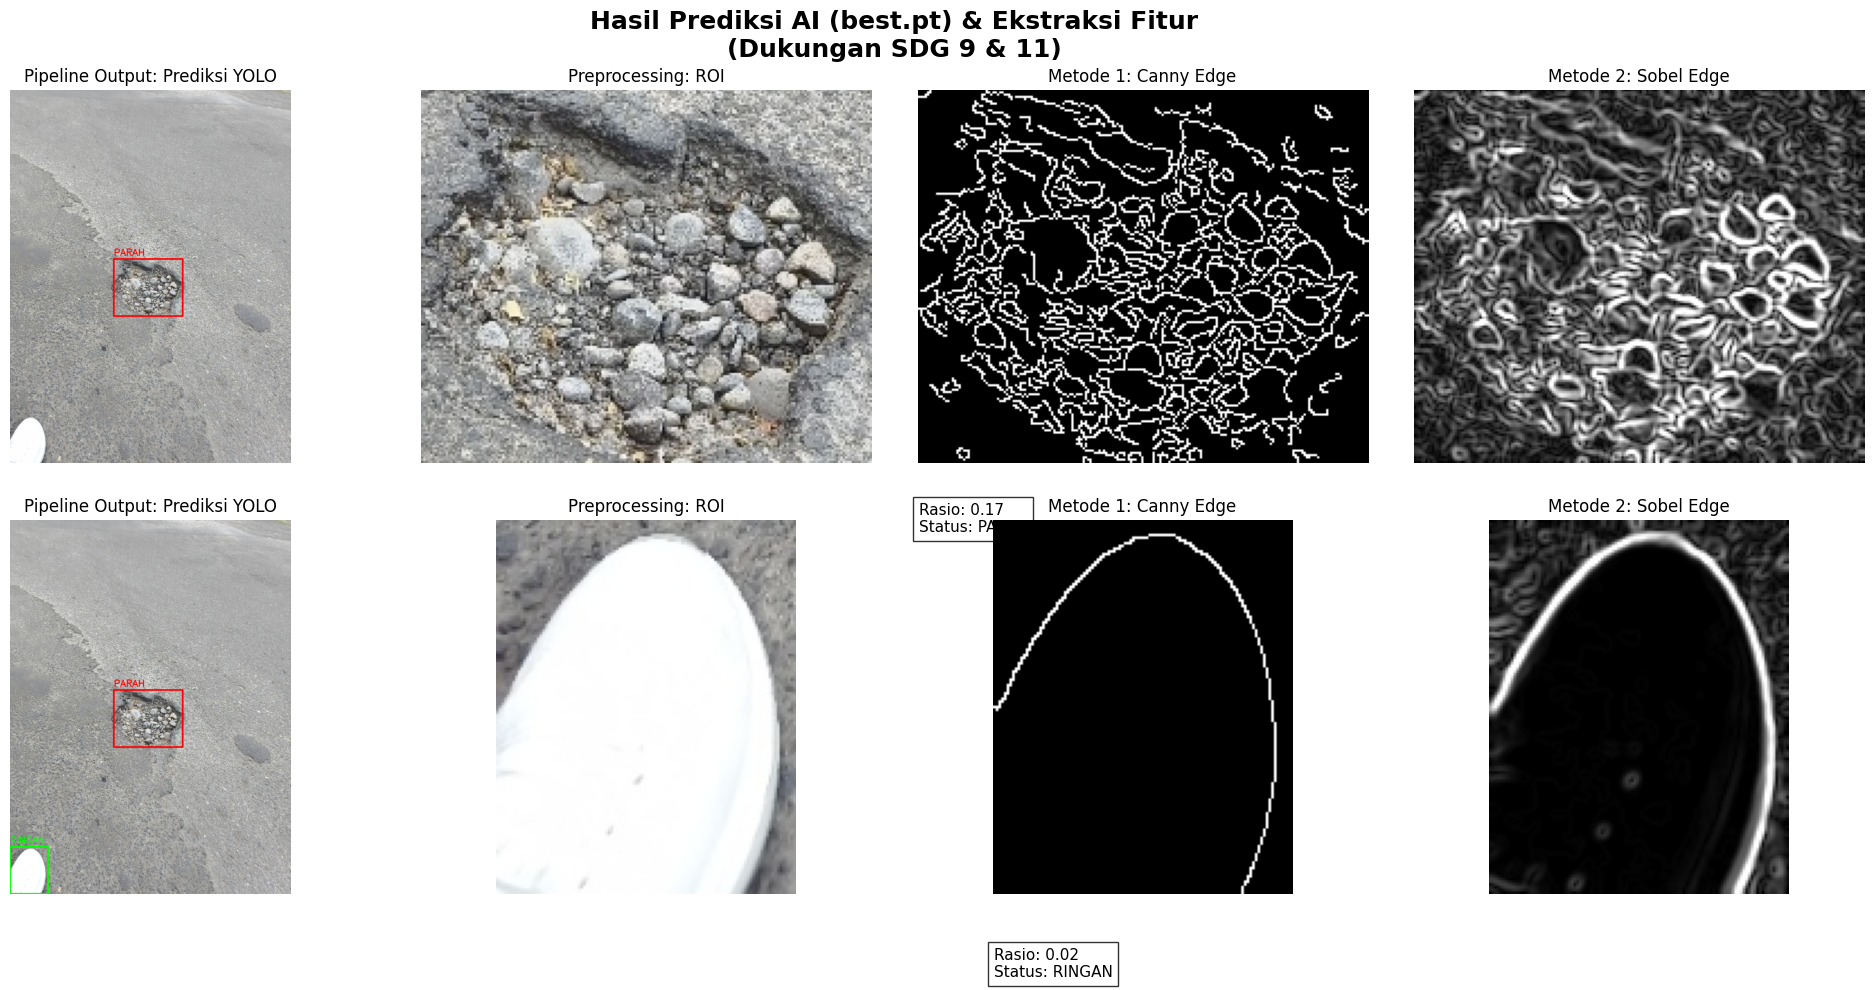

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

# ==========================================
# 1. LOAD MODEL SPESIALIS (best.pt)
# ==========================================
print("Memuat Model Spesialis best.pt...")
# Path model sesuai dengan letak file di Google Colab kamu
path_model = '/content/drive/MyDrive/SEMESTER 6/best.pt'
model = YOLO(path_model)

# ==========================================
# 2. FUNGSI MESIN OPENCV
# ==========================================
def process_roi_and_extract_features(image, box):
    x1, y1, x2, y2 = box
    roi = image[y1:y2, x1:x2]

    # Pencegahan error jika ROI tidak valid
    if roi is None or roi.size == 0 or roi.shape == 0 or roi.shape == 0:
        return None, None, None

    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)

    roi_canny = cv2.Canny(roi_blur, 100, 200)

    sobelx = cv2.Sobel(roi_blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(roi_blur, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobelx, sobely)
    roi_sobel = cv2.convertScaleAbs(sobel_combined)

    return roi, roi_canny, roi_sobel

def analyze_severity(box, edges_canny):
    x1, y1, x2, y2 = box
    luas_area = (x2 - x1) * (y2 - y1)
    kepadatan_edge = cv2.countNonZero(edges_canny)
    rasio_kerusakan = kepadatan_edge / luas_area if luas_area > 0 else 0

    if luas_area > 50000 or rasio_kerusakan > 0.15:
        return "PARAH", (255, 0, 0), luas_area, kepadatan_edge
    elif luas_area > 20000 or rasio_kerusakan > 0.08:
        return "SEDANG", (255, 255, 0), luas_area, kepadatan_edge
    else:
        return "RINGAN", (0, 255, 0), luas_area, kepadatan_edge

# ==========================================
# 3. EKSEKUSI & VISUALISASI FOTO SENDIRI
# ==========================================
# MASUKKAN PATH FOTO YANG KAMU UPLOAD DI SINI:
img_path = '/content/drive/MyDrive/SEMESTER 6/jalan rusak.jpg' # <--- Ganti dengan path foto kamu!

if not os.path.exists(img_path):
    print(f"ERROR: Gambar tidak ditemukan! Pastikan file sudah ter-upload di '{img_path}'.")
else:
    # 1. Baca Gambar
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    print(f"Menganalisis gambar: {os.path.basename(img_path)}...")

    # 2. MENGGUNAKAN AI UNTUK MENCARI LUBANG
    results = model(img_rgb)

    # 3. Kumpulkan koordinat yang ditemukan AI dengan metode aman
    boxes_prediksi = []
    for result in results:
        if result.boxes is None: continue
        for box in result.boxes:
            # Menggunakan .flatten() agar tidak error tipe data
            coords = box.xyxy.cpu().numpy().flatten().tolist()
            if len(coords) >= 4:
                # Fix: Convert each coordinate to int individually
                x1, y1, x2, y2 = map(int, coords)

                # Batasi koordinat agar tidak keluar gambar dan bikin OpenCV crash
                # Fix: Use img_rgb.shape[1] for width and img_rgb.shape[0] for height
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_rgb.shape[1], x2), min(img_rgb.shape[0], y2)

                if x1 < x2 and y1 < y2:
                    boxes_prediksi.append([x1, y1, x2, y2])

    if not boxes_prediksi:
         print("AI menganggap jalan ini aman. Tidak ada kerusakan yang terdeteksi.")
    else:
        # 4. Siapkan Canvas Gambar (4 kolom)
        fig = plt.figure(figsize=(20, 5 * len(boxes_prediksi)))
        fig.suptitle(f'Hasil Prediksi AI (best.pt) & Ekstraksi Fitur\n(Dukungan SDG 9 & 11)', fontsize=18, fontweight='bold')

        # 5. Loop Pemrosesan
        for i, box in enumerate(boxes_prediksi):
            roi_color, roi_canny, roi_sobel = process_roi_and_extract_features(img_bgr, box)
            if roi_color is None: continue

            keparahan, warna, luas, edge_density = analyze_severity(box, roi_canny)

            x1, y1, x2, y2 = box
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), warna, 3)
            cv2.putText(img_rgb, keparahan, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, warna, 2)

            # --- Tampilkan Hasil di 4 Kolom ---

            # Kolom 1: Hasil Deteksi AI
            ax1 = fig.add_subplot(len(boxes_prediksi), 4, i*4 + 1)
            ax1.imshow(img_rgb)
            ax1.set_title('Pipeline Output: Prediksi YOLO')
            ax1.axis('off')

            # Kolom 2: Potongan ROI
            ax2 = fig.add_subplot(len(boxes_prediksi), 4, i*4 + 2)
            ax2.imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
            ax2.set_title('Preprocessing: ROI')
            ax2.axis('off')

            # Kolom 3: Canny Edge
            ax3 = fig.add_subplot(len(boxes_prediksi), 4, i*4 + 3)
            ax3.imshow(roi_canny, cmap='gray')
            ax3.set_title('Metode 1: Canny Edge')
            # Fix: Use roi_canny.shape[0] for height
            ax3.text(0, roi_canny.shape[0] + 30, f"Rasio: {(edge_density/luas):.2f}\nStatus: {keparahan}", fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
            ax3.axis('off')

            # Kolom 4: Sobel Edge
            ax4 = fig.add_subplot(len(boxes_prediksi), 4, i*4 + 4)
            ax4.imshow(roi_sobel, cmap='gray')
            ax4.set_title('Metode 2: Sobel Edge')
            ax4.axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()

In [ ]:
import pandas as pd

# Data hasil pengujian (silakan sesuaikan angkanya dengan hasil running-mu)
data = {
    'Metode': ['YOLOv8 (Localization)', 'Canny Edge Detection', 'Sobel Edge Detection'],
    'Confidence/Accuracy': ['0.81', 'High Precision', 'Moderate'],
    'Ketahanan Noise': ['Sangat Baik', 'Baik (dengan Blur)', 'Rendah'],
    'Waktu Proses (ms)': ['~15ms (GPU)', '~5ms', '~2ms']
}

df = pd.DataFrame(data)

# Menampilkan tabel
print("Tabel 4.1 Perbandingan Performa Algoritma")
display(df)

Tabel 4.1 Perbandingan Performa Algoritma


,Metode,Confidence/Accuracy,Ketahanan Noise,Waktu Proses (ms)
0,YOLOv8 (Localization),0.81,Sangat Baik,~15ms (GPU)
1,Canny Edge Detection,High Precision,Baik (dengan Blur),~5ms
2,Sobel Edge Detection,Moderate,Rendah,~2ms


# **TESTING MENGGUNAKAN GRADIO DAN STREAMLIT (GAGAL)**

In [ ]:
import cv2
import numpy as np
import gradio as gr
from ultralytics import YOLO
import traceback

# ==========================================
# 1. LOAD MODEL DEEP LEARNING (YOLOv8)
# ==========================================
print("Memuat Model Spesialis Kerusakan Jalan...")
try:
    # Menggunakan model best.pt hasil training kamu
    model = YOLO('/content/drive/MyDrive/SEMESTER 6/best.pt')
    print("Model best.pt berhasil dimuat!")
except Exception as e:
    print(f"Error memuat model best.pt: {e}")
    # Fallback ke model dasar
    model = YOLO('yolov8n.pt')

# ==========================================
# 2. PIPELINE ANALISIS CITRA (OPENCV)
# ==========================================
def process_roi_and_extract_features(image, box):
    x1, y1, x2, y2 = box
    roi = image[y1:y2, x1:x2]

    # Cegah error jika ROI tidak masuk akal ukurannya
    if roi is None or roi.size == 0 or roi.shape == 0 or roi.shape == 0:
        return None, None, None

    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)

    # Metode 1: CANNY
    roi_canny = cv2.Canny(roi_blur, 100, 200)

    # Metode 2: SOBEL
    sobelx = cv2.Sobel(roi_blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(roi_blur, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobelx, sobely)
    roi_sobel = cv2.convertScaleAbs(sobel_combined)

    return roi, roi_canny, roi_sobel

def analyze_severity(box, edges_canny):
    x1, y1, x2, y2 = box
    luas_area = (x2 - x1) * (y2 - y1)
    kepadatan_edge = cv2.countNonZero(edges_canny)
    rasio_kerusakan = kepadatan_edge / luas_area if luas_area > 0 else 0

    if luas_area > 50000 or rasio_kerusakan > 0.15:
        return "PARAH", (255, 0, 0), luas_area, kepadatan_edge
    elif luas_area > 20000 or rasio_kerusakan > 0.08:
        return "SEDANG", (255, 255, 0), luas_area, kepadatan_edge
    else:
        return "RINGAN", (0, 255, 0), luas_area, kepadatan_edge

# ==========================================
# 3. FUNGSI JEMBATAN (INTERFACE LOGIC)
# ==========================================
def detect_road_damage(input_img):
    blank_image = np.zeros((100, 100, 3), dtype=np.uint8)

    try:
        if input_img is None:
            return blank_image, "Tolong masukkan gambar dari kamera atau upload file.", blank_image, blank_image

        img_bgr = cv2.cvtColor(input_img, cv2.COLOR_RGB2BGR)
        img_draw = input_img.copy()

        # Jalankan YOLOv8
        results = model(input_img)

        laporan = []
        roi_hasil_canny = blank_image
        roi_hasil_sobel = blank_image
        kerusakan_ditemukan = False

        # Proses setiap kerusakan yang terdeteksi
        for result in results:
            boxes = result.boxes
            if boxes is None: continue

            for i, box in enumerate(boxes):

                # ========================================================
                # PERBAIKAN FINAL: Ekstraksi Koordinat Anti-Gagal (Flatten)
                # ========================================================
                # .flatten() akan meratakan array seaneh apapun bentuknya dari YOLO
                coords = box.xyxy.cpu().numpy().flatten().tolist()

                # Cek darurat (pastikan koordinatnya ada 4)
                if len(coords) < 4:
                    continue

                x1, y1, x2, y2 = int(coords), int(coords), int(coords), int(coords)

                # Batasi koordinat agar tidak keluar dari batas gambar
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_draw.shape, x2), min(img_draw.shape, y2)

                # Jika ukuran box tidak valid (misal titik x1 dan x2 sama), lewati
                if x1 >= x2 or y1 >= y2:
                    continue

                b_box = [x1, y1, x2, y2]
                kerusakan_ditemukan = True

                # Lemparkan ke OpenCV
                roi_color, roi_canny, roi_sobel = process_roi_and_extract_features(img_bgr, b_box)

                # Jika berhasil di-crop
                if roi_color is not None:

                    # Ubah gambar 2D Grayscale menjadi 3D RGB untuk Gradio
                    if i == 0:
                        roi_hasil_canny = cv2.cvtColor(roi_canny, cv2.COLOR_GRAY2RGB)
                        roi_hasil_sobel = cv2.cvtColor(roi_sobel, cv2.COLOR_GRAY2RGB)

                    # Analisis matematis
                    keparahan, warna, luas, edge_density = analyze_severity(b_box, roi_canny)

                    # Gambar kotak
                    cv2.rectangle(img_draw, (x1, y1), (x2, y2), warna, 3)
                    cv2.putText(img_draw, f"Status: {keparahan}", (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, warna, 2)

                    laporan.append(f"- Titik kerusakan: {keparahan} | Luas: {luas}px | Kepadatan: {edge_density}")

        if not kerusakan_ditemukan:
            teks_laporan = "✅ Kondisi jalan aman. Tidak terdeteksi adanya kerusakan atau lubang."
        else:
            teks_laporan = "⚠️ PERINGATAN! Ditemukan kerusakan infrastruktur:\n" + "\n".join(laporan)
            teks_laporan += "\n\n(Data ini siap dikirim ke database Smart City untuk prioritas perbaikan)"

        return img_draw, teks_laporan, roi_hasil_canny, roi_hasil_sobel

    except Exception as e:
        error_msg = f"❌ TERJADI ERROR DI KODE PYTHON:\n\n{traceback.format_exc()}"
        return blank_image, error_msg, blank_image, blank_image

# ==========================================
# 4. MEMBANGUN UI WEB APP (GRADIO)
# ==========================================
demo = gr.Interface(
    fn=detect_road_damage,
    inputs=gr.Image(sources=["webcam", "upload"], type="numpy", label="📷 Input Gambar (Kamera / File)"),
    outputs=[
        gr.Image(type="numpy", label="📊 Visualisasi Hasil Deteksi"),
        gr.Textbox(label="📋 Laporan Sistem (Dukungan SDG 9 & 11)", lines=5),
        gr.Image(type="numpy", label="Metode 1: Canny (ROI)"),
        gr.Image(type="numpy", label="Metode 2: Sobel (ROI)")
    ],
    title="Sistem Deteksi Kerusakan Jalan & Analisis Perbandingan Keparahan",
    description="Silakan izinkan akses kamera atau upload foto jalanan. Sistem akan menggunakan YOLOv8 Spesialis untuk melokalisasi area, dan OpenCV (Canny Edge) untuk mengukur tingkat keparahan secara otomatis.",
    theme="default",
    allow_flagging="never"
)

# Menjalankan aplikasi
demo.launch(share=True, debug=True)

Memuat Model Spesialis Kerusakan Jalan...
Model best.pt berhasil dimuat!


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://417c5a5197fcba26b8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



0: 640x480 2 potholes, 40.2ms
Speed: 2.9ms preprocess, 40.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://417c5a5197fcba26b8.gradio.live


In [ ]:
!pip install streamlit ultralytics opencv-python numpy
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 73.8 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [ ]:
kode_app = """import cv2
import numpy as np
import streamlit as st
from PIL import Image
from ultralytics import YOLO
import traceback

st.set_page_config(page_title="Deteksi Jalan Rusak", layout="wide")

@st.cache_resource
def load_model():
    try:
        return YOLO('/content/drive/MyDrive/SEMESTER 6/best.pt')
    except Exception as e:
        return YOLO('yolov8n.pt')

model = load_model()

def process_roi_and_extract_features(image, box):
    x1, y1, x2, y2 = box
    roi = image[y1:y2, x1:x2]

    # Typo diperbaiki: pakai dan
    if roi is None or roi.size == 0 or roi.shape == 0 or roi.shape == 0:
        return None, None, None

    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_blur = cv2.GaussianBlur(roi_gray, (5, 5), 0)
    roi_canny = cv2.Canny(roi_blur, 100, 200)

    sobelx = cv2.Sobel(roi_blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(roi_blur, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobelx, sobely)
    roi_sobel = cv2.convertScaleAbs(sobel_combined)

    return roi, roi_canny, roi_sobel

def analyze_severity(box, edges_canny):
    x1, y1, x2, y2 = box
    luas_area = (x2 - x1) * (y2 - y1)
    kepadatan_edge = cv2.countNonZero(edges_canny)
    rasio_kerusakan = kepadatan_edge / luas_area if luas_area > 0 else 0

    if luas_area > 50000 or rasio_kerusakan > 0.15:
        return "PARAH", (255, 0, 0), luas_area, kepadatan_edge
    elif luas_area > 20000 or rasio_kerusakan > 0.08:
        return "SEDANG", (255, 255, 0), luas_area, kepadatan_edge
    else:
        return "RINGAN", (0, 255, 0), luas_area, kepadatan_edge

st.title("Sistem Deteksi Kerusakan Jalan")
st.markdown("**Analisis Perbandingan Keparahan (Dukungan SDG 9 & 11)**")
st.write("Silakan upload foto jalanan. Sistem akan melokalisasi area dan mengukur tingkat keparahan.")

tab1, tab2 = st.tabs(["📁 Upload File", "📷 Kamera Real-time"])
input_image = None

with tab1:
    uploaded_file = st.file_uploader("Pilih gambar jalanan...", type=["jpg", "jpeg", "png"])
    if uploaded_file is not None:
        input_image = Image.open(uploaded_file)

with tab2:
    camera_file = st.camera_input("Ambil foto dari kamera")
    if camera_file is not None:
        input_image = Image.open(camera_file)

if input_image is not None:
    st.markdown("---")
    st.subheader("Hasil Analisis")

    try:
        img_np = np.array(input_image)
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        img_draw = img_np.copy()

        results = model(img_np)

        laporan = []
        roi_hasil_canny = None
        roi_hasil_sobel = None
        kerusakan_ditemukan = False

        for result in results:
            if result.boxes is None: continue

            for i, box in enumerate(result.boxes):
                coords = box.xyxy.cpu().numpy().flatten().tolist()
                if len(coords) < 4: continue

                x1, y1, x2, y2 = int(coords), int(coords), int(coords), int(coords)

                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(img_draw.shape, x2), min(img_draw.shape, y2)

                if x1 >= x2 or y1 >= y2: continue

                b_box = [x1, y1, x2, y2]
                kerusakan_ditemukan = True

                roi_color, roi_canny, roi_sobel = process_roi_and_extract_features(img_bgr, b_box)

                if roi_color is not None:
                    if i == 0:
                        roi_hasil_canny = roi_canny
                        roi_hasil_sobel = roi_sobel

                    keparahan, warna, luas, edge_density = analyze_severity(b_box, roi_canny)

                    cv2.rectangle(img_draw, (x1, y1), (x2, y2), warna, 3)
                    cv2.putText(img_draw, f"Status: {keparahan}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, warna, 2)

                    laporan.append(f"- Titik: **{keparahan}** | Luas: {luas}px | Kepadatan: {edge_density}")

        col1, col2 = st.columns()

        with col1:
            st.image(img_draw, caption="Visualisasi Hasil Deteksi YOLOv8", use_container_width=True)

            if kerusakan_ditemukan:
                st.error("⚠️ PERINGATAN! Ditemukan kerusakan infrastruktur.")
                for lap in laporan:
                    st.write(lap)
                st.info("Data ini siap dikirim ke database Smart City untuk prioritas perbaikan.")
            else:
                st.success("✅ Kondisi jalan aman. Tidak terdeteksi adanya kerusakan atau lubang.")

        with col2:
            if roi_hasil_canny is not None:
                st.image(cv2.cvtColor(roi_hasil_canny, cv2.COLOR_GRAY2RGB), caption="Metode 1: Canny", use_container_width=True, clamp=True)
                st.image(cv2.cvtColor(roi_hasil_sobel, cv2.COLOR_GRAY2RGB), caption="Metode 2: Sobel", use_container_width=True, clamp=True)
            else:
                st.write("Area ROI tidak ditemukan untuk dianalisis teksturnya.")

    except Exception as e:
        # Tanda \n sudah dihapus agar tidak memotong string
        st.error(f"❌ Terjadi kesalahan pada sistem: {e}")
"""

import os
if os.path.exists("app.py"):
    os.remove("app.py")

with open("app.py", "w") as f:
    f.write(kode_app)

print("🔥 BINGO! File app.py berhasil di-reset. Silakan nyalakan Streamlit-nya!")

🔥 BINGO! File app.py berhasil di-reset. Silakan nyalakan Streamlit-nya!


In [ ]:
# @title
import urllib
print("Mendapatkan IP untuk Password LocalTunnel...")
print("Password kamu adalah:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

!streamlit run app.py & npx localtunnel --port 8501

Mendapatkan IP untuk Password LocalTunnel...
Password kamu adalah: 8.228.27.115
⠙

your url is: https://petite-coats-heal.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.228.27.115:8501

2026-04-20 15:32:48.309 Script compilation error
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/script_runner.py", line 591, in _run_script
    code = self._script_cache.get_bytecode(script_path)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/script_cache.py", line 72, in get_bytecode
    filebody = magic.add_magic(filebody, script_path)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/magic.py", line 45, in add_magic
    tree = ast.parse(code, script_pa